# 📞 SERVIER — Pipeline Complet de Prévision : *Offered Contacts*

| | |
|---|---|
| **Client** | Servier |
| **Queues** | Servier French · Servier English · Servier French Password · Servier Spanish |
| **Cible** | `Offered contacts` |
| **Modèles** | SARIMA · XGBoost · LightGBM · Prophet |
| **Métriques** | MAE · MAPE · R² |
| **Horizon** | J+7 & J+30 |


## 0. Imports & Configuration

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
import lightgbm as lgb
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from prophet import Prophet

DATA_PATH  = "../data/Servier_KPIs.csv"
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

C = dict(primary="#2C3E50", secondary="#2980B9", accent="#E74C3C",
         success="#27AE60", warning="#F39C12",
         train="#3498DB", val="#F39C12", test="#E74C3C", pred="#2ECC71")
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"#FAFAFA",
                     "axes.grid":True,"grid.alpha":0.4,
                     "axes.spines.top":False,"axes.spines.right":False})
SEED = 42; np.random.seed(SEED)

TARGET = "Offered contacts"    # colonne cible directement disponible

def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, name), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print(f"  [SAVED] {name}")

def compute_metrics(y_true, y_pred, label=""):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f"  {'─'*40}")
        print(f"  Modèle : {label}")
        print(f"  MAE    : {mae:.2f}")
        print(f"  RMSE   : {rmse:.2f}")
        print(f"  MAPE   : {mape:.2f}%")
        print(f"  R²     : {r2:.4f}")
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, R2=r2)

results_store = {}
print("✅ Imports OK")


✅ Imports OK


## 1. Chargement & Aperçu

In [2]:
raw = pd.read_csv(DATA_PATH, sep=None, engine="python")

print(f"Shape         : {raw.shape}")
print(f"Séparateur    : auto-détecté")
print(f"Colonnes ({len(raw.columns)}) : {list(raw.columns)}")
print(f"\nQueues présentes :")
for q, cnt in raw["Queue"].value_counts().items():
    print(f"  • {q:40s}  {cnt:,} lignes")
print(f"\nColonne date  : 'Day'")
print(f"Période       : {raw['Day'].min()}  →  {raw['Day'].max()}")
print(f"\nNaN top 10 :")
print(raw.isnull().sum().sort_values(ascending=False).head(10).to_string())

Shape         : (1885, 50)
Séparateur    : auto-détecté
Colonnes (50) : ['Day', 'Period', 'Queue', 'Contacts abandoned in 20 seconds', 'Contacts abandoned in 30 seconds', 'Contacts abandoned in 45 seconds', 'Contacts abandoned in 60 seconds', 'Contacts abandoned in 90 seconds', 'Contacts abandoned in 180 seconds', 'Contacts answered in 20 seconds', 'Contacts answered in 30 seconds', 'Contacts answered in 45 seconds', 'Contacts answered in 60 seconds', 'Contacts answered in 90 seconds', 'Contacts answered in 180 seconds', 'Service level 60 seconds', 'Service level 120 seconds', 'Agent interaction time', 'API contacts', 'API contacts handled', 'Average agent interaction time', 'Average customer hold time', 'Average handle time', 'Average queue abandon time', 'Average queue answer time', 'Callback contacts', 'Callback contacts handled', 'Contacts abandoned', 'Contacts handled incoming', 'Contacts handled outbound', 'Contacts queued', 'Contacts abandoned in 40 seconds', 'Contacts answered 

## 2. Préparation & Agrégation journalière

Jours manquants : 38
Shape final  : (701, 33)
Plage        : 2024-06-01 → 2026-05-02
NaN restants : 0

Offered contacts — stats :
count    701.00
mean      39.64
std       30.11
min        1.00
25%        8.00
50%       40.00
75%       58.00
max      179.00


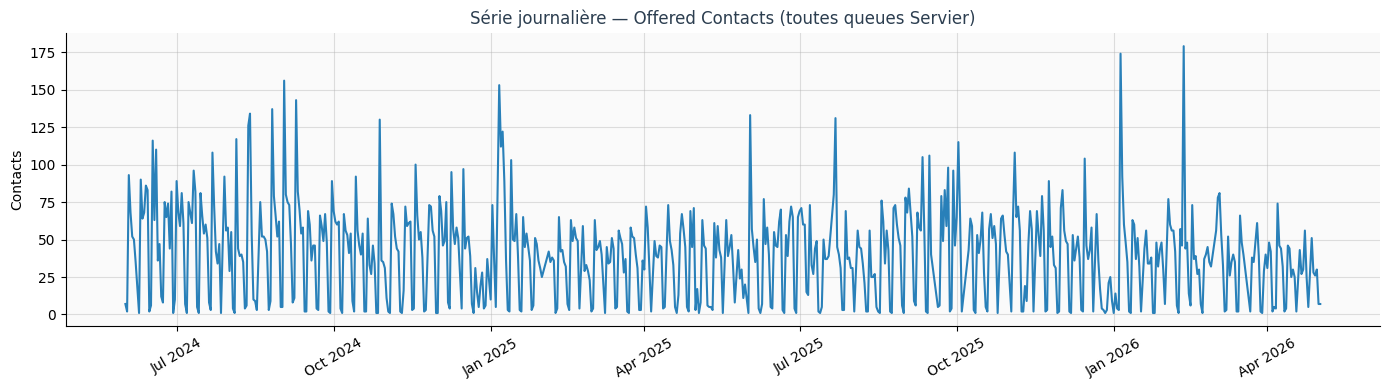

  [SAVED] 00_serie_globale.png


In [3]:
# ── Parse date ────────────────────────────────────────────────────────────────
raw["Day"] = pd.to_datetime(raw["Day"], dayfirst=True, errors="coerce")
raw = raw.dropna(subset=["Day"])

# ── Colonnes numériques ───────────────────────────────────────────────────────
sum_cols = [c for c in [
    "Offered contacts", "Handled contacts", "Abandoned contacts",
    "Answered in SLA",  "Abandon in SLA",   "Answered out SLA", "Abandon out SLA",
    "Contacts put on hold", "Contacts queued",
    "Contacts handled incoming", "Contacts handled outbound",
    "Contacts abandoned in 20 seconds", "Contacts abandoned in 30 seconds",
    "Contacts abandoned in 45 seconds", "Contacts abandoned in 60 seconds",
    "Contacts answered in 20 seconds",  "Contacts answered in 30 seconds",
    "Contacts answered in 45 seconds",  "Contacts answered in 60 seconds",
    "Agent interaction time",
] if c in raw.columns]

mean_cols = [c for c in [
    "Service level 60 seconds", "Service level 120 seconds",
    "Average agent interaction time", "Average customer hold time",
    "Average handle time", "Average queue answer time",
    "Average queue abandon time", "Answered Rate", "Abd Rate",
] if c in raw.columns]

# ── Nettoyage % → float et durées hh:mm:ss → secondes ───────────────────────
def hms_to_sec(s):
    try:
        p = str(s).strip().split(":")
        if len(p) == 3: return int(p[0])*3600 + int(p[1])*60 + int(p[2])
        if len(p) == 2: return int(p[0])*60   + int(p[1])
    except: pass
    return np.nan

for col in ["Service level 60 seconds","Service level 120 seconds","Answered Rate","Abd Rate"]:
    if col in raw.columns:
        raw[col] = pd.to_numeric(
            raw[col].astype(str).str.replace("%","",regex=False).str.strip(), errors="coerce")

for col in ["ASA","Avg TTC","Avg Hold","Avg AHT"]:
    if col in raw.columns:
        raw[col+"_sec"] = raw[col].apply(hms_to_sec)
        if col+"_sec" not in mean_cols:
            mean_cols.append(col+"_sec")

# ── Colonnes numériques → numeric ─────────────────────────────────────────────
for col in sum_cols + mean_cols:
    if col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")

# ── Agrégation journalière ────────────────────────────────────────────────────
agg = {c:"sum"  for c in sum_cols  if c in raw.columns}
agg.update({c:"mean" for c in mean_cols if c in raw.columns})

df = (raw.groupby("Day").agg(agg)
        .reset_index().sort_values("Day").set_index("Day"))

# Réindexation pour combler les trous
full_idx = pd.date_range(df.index.min(), df.index.max(), freq="D")
print(f"Jours manquants : {len(set(full_idx) - set(df.index))}")
df = df.reindex(full_idx)

# Imputation
for c in [c for c in sum_cols if c in df.columns]:
    df[c] = df[c].interpolate("time").ffill().bfill()
for c in [c for c in mean_cols if c in df.columns]:
    df[c] = df[c].fillna(df[c].rolling(7, min_periods=1).mean()).ffill().bfill()

# Mettre à jour sum_cols/mean_cols avec ce qui existe réellement dans df
sum_cols  = [c for c in sum_cols  if c in df.columns]
mean_cols = [c for c in mean_cols if c in df.columns]

print(f"Shape final  : {df.shape}")
print(f"Plage        : {df.index.min().date()} → {df.index.max().date()}")
print(f"NaN restants : {df.isnull().sum().sum()}")
print(f"\n{TARGET} — stats :")
print(df[TARGET].describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df[TARGET], color=C["secondary"], lw=1.5)
ax.set_title("Série journalière — Offered Contacts (toutes queues Servier)",
             fontsize=12, color=C["primary"])
ax.set_ylabel("Contacts")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=30)
save_fig("00_serie_globale.png")


## 3. Analyse Exploratoire (EDA)

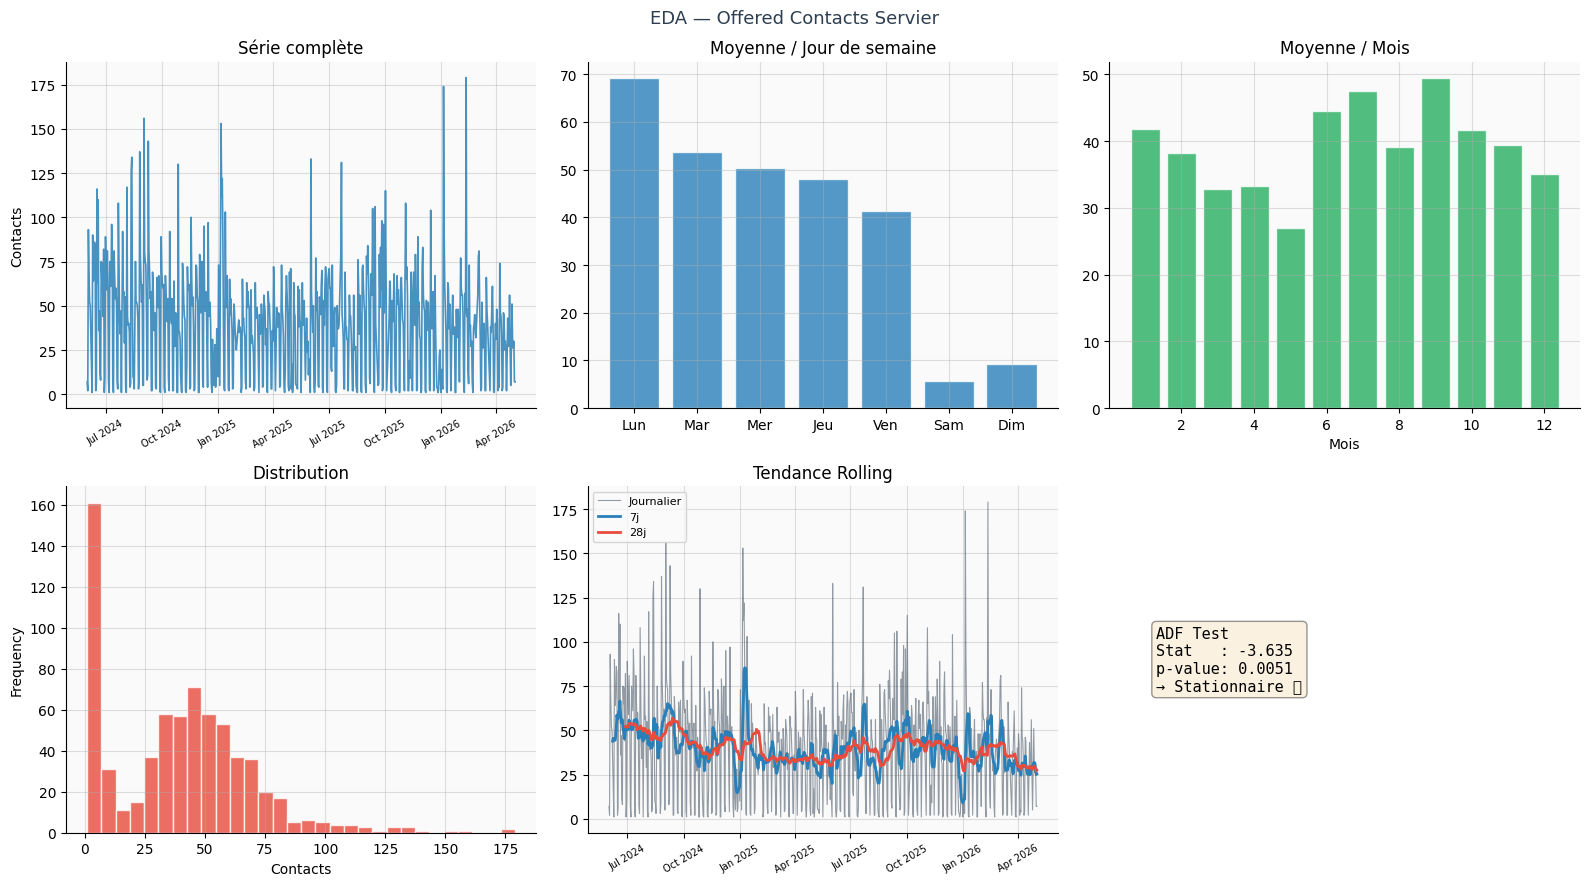

  [SAVED] 01_eda.png
ADF p-value : 0.0051


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — Offered Contacts Servier", fontsize=13, color=C["primary"])

ax = axes[0, 0]
ax.plot(df.index, df[TARGET], color=C["secondary"], lw=1.2, alpha=0.85)
ax.set_title("Série complète"); ax.set_ylabel("Contacts")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=30, fontsize=7)

ax = axes[0, 1]
dow = df.groupby(df.index.dayofweek)[TARGET].mean()
ax.bar(dow.index, dow.values, color=C["secondary"], alpha=0.8, edgecolor="white")
ax.set_xticks(range(7))
ax.set_xticklabels(["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"])
ax.set_title("Moyenne / Jour de semaine")

ax = axes[0, 2]
mon = df.groupby(df.index.month)[TARGET].mean()
ax.bar(mon.index, mon.values, color=C["success"], alpha=0.8, edgecolor="white")
ax.set_title("Moyenne / Mois"); ax.set_xlabel("Mois")

ax = axes[1, 0]
df[TARGET].dropna().plot(kind="hist", bins=30, ax=ax,
    color=C["accent"], edgecolor="white", alpha=0.8)
ax.set_title("Distribution"); ax.set_xlabel("Contacts")

ax = axes[1, 1]
ax.plot(df.index, df[TARGET], color=C["primary"], lw=0.8, alpha=0.5, label="Journalier")
ax.plot(df.index, df[TARGET].rolling(7).mean(),  color=C["secondary"], lw=2, label="7j")
ax.plot(df.index, df[TARGET].rolling(28).mean(), color=C["accent"],    lw=2, label="28j")
ax.legend(fontsize=8); ax.set_title("Tendance Rolling")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=30, fontsize=7)

ax = axes[1, 2]
series_clean = df[TARGET].dropna()
adf = adfuller(series_clean, autolag="AIC")
txt = (f"ADF Test\nStat   : {adf[0]:.3f}\n"
       f"p-value: {adf[1]:.4f}\n"
       f"→ {'Stationnaire ✅' if adf[1]<0.05 else 'Non-stationnaire ⚠️'}")
ax.axis("off")
ax.text(0.1, 0.5, txt, fontsize=11, family="monospace",
        verticalalignment="center",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.4))

save_fig("01_eda.png")
print(f"ADF p-value : {adf[1]:.4f}")


## 4. Feature Engineering

In [5]:
d = df[[TARGET] + mean_cols].copy().dropna(subset=[TARGET])

d["day_of_week"] = d.index.dayofweek
d["month"]       = d.index.month
d["week"]        = d.index.isocalendar().week.astype(int)
d["is_weekend"]  = (d.index.dayofweek >= 5).astype(int)
d["quarter"]     = d.index.quarter

for lag in [1, 2, 3, 7, 14, 21, 28]:
    d[f"lag_{lag}"] = d[TARGET].shift(lag)

for w in [7, 14, 28]:
    d[f"rolling_mean_{w}"] = d[TARGET].shift(1).rolling(w, min_periods=1).mean()
    d[f"rolling_std_{w}"]  = d[TARGET].shift(1).rolling(w, min_periods=1).std().fillna(0)

d["ema_7"]  = d[TARGET].shift(1).ewm(span=7,  adjust=False).mean()
d["ema_14"] = d[TARGET].shift(1).ewm(span=14, adjust=False).mean()
d["diff_1"] = d[TARGET].diff(1)
d["diff_7"] = d[TARGET].diff(7)

d = d.dropna()
feature_cols = [c for c in d.columns if c != TARGET]
print(f"Lignes : {len(d)}")
print(f"Features ({len(feature_cols)}) : {feature_cols}")


Lignes : 673
Features (35) : ['Service level 60 seconds', 'Service level 120 seconds', 'Average agent interaction time', 'Average customer hold time', 'Average handle time', 'Average queue answer time', 'Average queue abandon time', 'Answered Rate', 'Abd Rate', 'ASA_sec', 'Avg TTC_sec', 'Avg Hold_sec', 'Avg AHT_sec', 'day_of_week', 'month', 'week', 'is_weekend', 'quarter', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'ema_7', 'ema_14', 'diff_1', 'diff_7']


## 5. Split Temporel — Train / Val / Test

Train : 506 jours  2024-06-29 → 2025-11-16
Val   : 100 jours  2025-11-17  → 2026-02-24
Test  :  67 jours  2026-02-25 → 2026-05-02


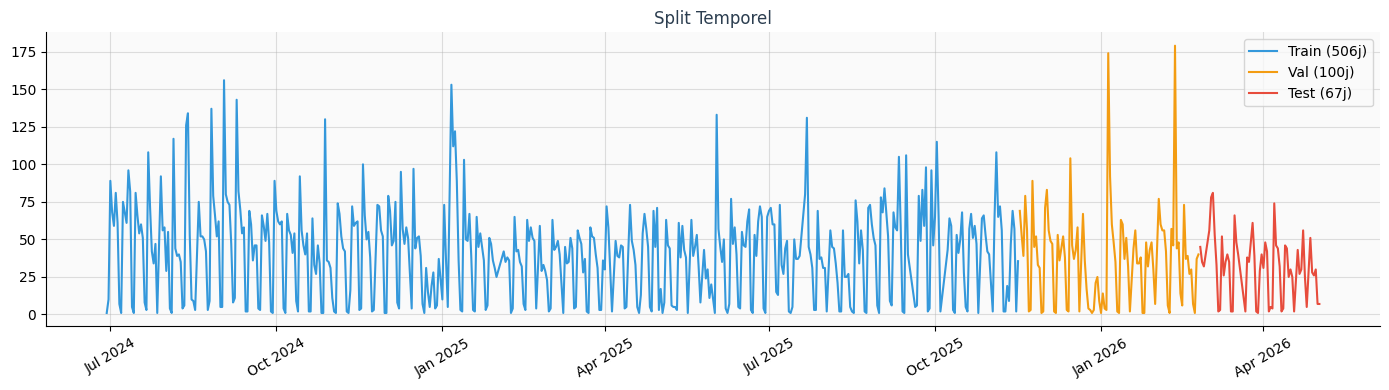

  [SAVED] 02_split.png


In [6]:
n      = len(d)
n_test = max(30, int(n * 0.10))
n_val  = max(30, int(n * 0.15))

d_test  = d.iloc[-n_test:]
d_val   = d.iloc[-(n_test+n_val):-n_test]
d_train = d.iloc[:-(n_test+n_val)]

X_train, y_train = d_train[feature_cols].values, d_train[TARGET].values
X_val,   y_val   = d_val[feature_cols].values,   d_val[TARGET].values
X_test,  y_test  = d_test[feature_cols].values,  d_test[TARGET].values

scaler    = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train : {len(d_train):3d} jours  {d_train.index[0].date()} → {d_train.index[-1].date()}")
print(f"Val   : {len(d_val):3d} jours  {d_val.index[0].date()}  → {d_val.index[-1].date()}")
print(f"Test  : {len(d_test):3d} jours  {d_test.index[0].date()} → {d_test.index[-1].date()}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(d_train.index, y_train, color=C["train"], lw=1.5, label=f"Train ({len(d_train)}j)")
ax.plot(d_val.index,   y_val,   color=C["val"],   lw=1.5, label=f"Val ({len(d_val)}j)")
ax.plot(d_test.index,  y_test,  color=C["test"],  lw=1.5, label=f"Test ({len(d_test)}j)")
ax.set_title("Split Temporel", fontsize=12, color=C["primary"])
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=30)
save_fig("02_split.png")


## 6. Modèle SARIMA

In [7]:
print("Entraînement SARIMA...")
sarima_series = pd.concat([d_train[TARGET], d_val[TARGET]])

sarima_model = pm.auto_arima(
    sarima_series, seasonal=True, m=7,
    stepwise=True, suppress_warnings=True,
    error_action="ignore", max_order=8,
    information_criterion="aic"
)
print(f"Ordre : {sarima_model.order} × {sarima_model.seasonal_order}")

sarima_preds = np.maximum(sarima_model.predict(n_periods=len(y_test)), 0)
results_store["SARIMA"] = compute_metrics(y_test, sarima_preds, "SARIMA")


Entraînement SARIMA...
Ordre : (2, 1, 1) × (1, 0, 1, 7)
  ────────────────────────────────────────
  Modèle : SARIMA
  MAE    : 12.64
  RMSE   : 16.84
  MAPE   : 98.87%
  R²     : 0.3037


## 7. Modèle XGBoost

  ────────────────────────────────────────
  Modèle : XGBoost
  MAE    : 2.39
  RMSE   : 3.32
  MAPE   : 20.35%
  R²     : 0.9729


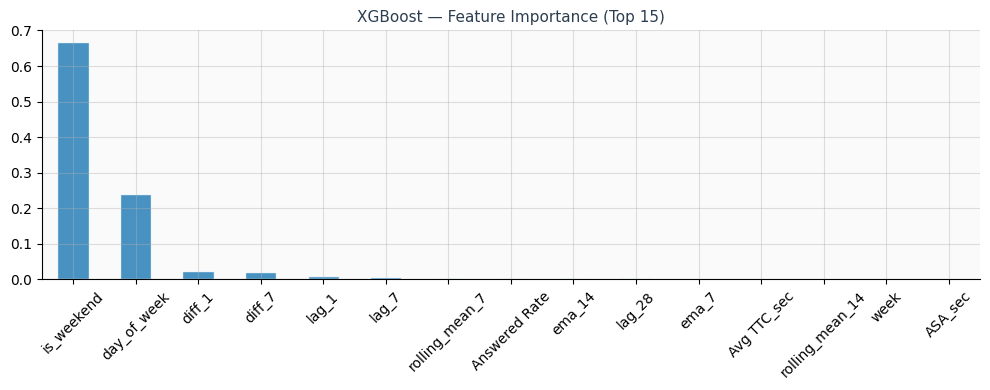

  [SAVED] 03_xgb_importance.png


In [8]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, early_stopping_rounds=30, eval_metric="rmse"
)
xgb_model.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)

pred_xgb_test = np.maximum(xgb_model.predict(X_test_s), 0)
results_store["XGBoost"] = compute_metrics(y_test, pred_xgb_test, "XGBoost")

fi = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
fi.head(15).plot(kind="bar", ax=ax, color=C["secondary"], edgecolor="white", alpha=0.85)
ax.set_title("XGBoost — Feature Importance (Top 15)", fontsize=11, color=C["primary"])
ax.tick_params(axis="x", rotation=45)
save_fig("03_xgb_importance.png")


## 8. Modèle LightGBM

In [9]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(period=-1)])

pred_lgb_test = np.maximum(lgb_model.predict(X_test_s), 0)
results_store["LightGBM"] = compute_metrics(y_test, pred_lgb_test, "LightGBM")


  ────────────────────────────────────────
  Modèle : LightGBM
  MAE    : 3.33
  RMSE   : 5.54
  MAPE   : 24.40%
  R²     : 0.9247


## 9. Modèle Prophet

In [10]:
prophet_df = (pd.concat([d_train[[TARGET]], d_val[[TARGET]]])
              .reset_index()
              .rename(columns={"index": "ds", TARGET: "y"}))

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                        daily_seasonality=False,
                        changepoint_prior_scale=0.05, seasonality_prior_scale=10)
prophet_model.fit(prophet_df)

fut = prophet_model.make_future_dataframe(periods=len(y_test), freq="D")
prophet_test_pred = np.maximum(
    prophet_model.predict(fut)["yhat"].iloc[-len(y_test):].values, 0)

results_store["Prophet"] = compute_metrics(y_test, prophet_test_pred, "Prophet")


14:10:57 - cmdstanpy - INFO - Chain [1] start processing
14:10:58 - cmdstanpy - INFO - Chain [1] done processing


  ────────────────────────────────────────
  Modèle : Prophet
  MAE    : 11.52
  RMSE   : 16.87
  MAPE   : 73.32%
  R²     : 0.3015


## 10. Comparaison des Modèles — MAE / MAPE / R²


  TABLEAU COMPARATIF
              MAE     RMSE     MAPE      R2
SARIMA    12.6446  16.8394  98.8707  0.3037
XGBoost    2.3939   3.3234  20.3531  0.9729
LightGBM   3.3290   5.5392  24.4006  0.9247
Prophet   11.5159  16.8663  73.3181  0.3015

🏆 MEILLEUR MODÈLE : XGBoost
   MAE  : 2.39  contacts/jour
   MAPE : 20.35%
   R²   : 0.9729


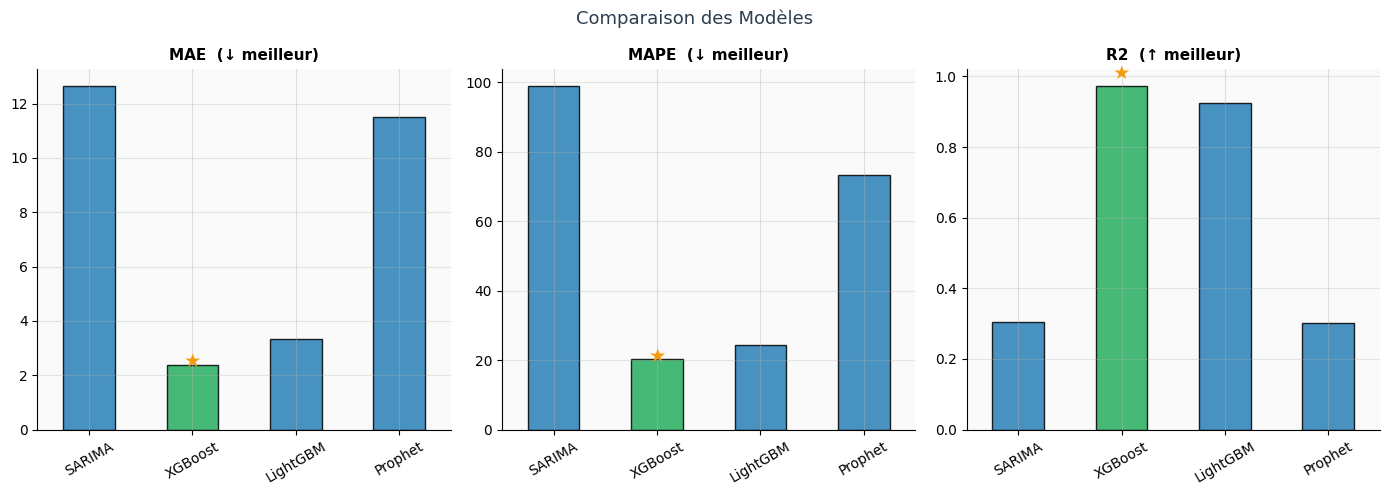

  [SAVED] 04_model_comparison.png
[SAVED] model_comparison.csv


In [11]:
results_df = (pd.DataFrame(results_store).T[["MAE","RMSE","MAPE","R2"]]
              .astype(float).round(4))

print("\n" + "="*58)
print("  TABLEAU COMPARATIF")
print("="*58)
print(results_df.to_string())

best_model = results_df["RMSE"].idxmin()
bm = results_df.loc[best_model]
print(f"\n🏆 MEILLEUR MODÈLE : {best_model}")
print(f"   MAE  : {bm['MAE']:.2f}  contacts/jour")
print(f"   MAPE : {bm['MAPE']:.2f}%")
print(f"   R²   : {bm['R2']:.4f}")

bar_colors = [C["success"] if i==best_model else C["secondary"] for i in results_df.index]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Comparaison des Modèles", fontsize=13, color=C["primary"])
for ax, (metric, better) in zip(axes, [("MAE","↓"),("MAPE","↓"),("R2","↑")]):
    results_df[metric].plot(kind="bar", ax=ax, color=bar_colors, edgecolor="black", alpha=0.85)
    ax.set_title(f"{metric}  ({better} meilleur)", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3, axis="y")
    for i,(idx,val) in enumerate(results_df[metric].items()):
        if idx==best_model:
            ax.text(i, val*(0.96 if better=="↓" else 1.02), "★",
                    ha="center", fontsize=14, color=C["warning"])
save_fig("04_model_comparison.png")
results_df.to_csv(os.path.join(OUTPUT_DIR,"model_comparison.csv"))
print("[SAVED] model_comparison.csv")


## 10.5 Modèle Ensembliste — XGBoost + Prophet

  Poids XGBoost  : 0.835
  Poids Prophet  : 0.165
  ────────────────────────────────────────
  Modèle : Ensemble (50/50)
  MAE    : 6.28
  RMSE   : 9.50
  MAPE   : 38.20%
  R²     : 0.7784
  ────────────────────────────────────────
  Modèle : Ensemble (w=0.84/0.16)
  MAE    : 3.24
  RMSE   : 4.94
  MAPE   : 23.60%
  R²     : 0.9400

  TABLEAU COMPARATIF ÉTENDU  (modèles individuels + ensembles)
                  MAE     RMSE     MAPE      R2
SARIMA        12.6446  16.8394  98.8707  0.3037
XGBoost        2.3939   3.3234  20.3531  0.9729
LightGBM       3.3290   5.5392  24.4006  0.9247
Prophet       11.5159  16.8663  73.3181  0.3015
Ensemble_avg   6.2750   9.5007  38.2018  0.7784
Ensemble_w     3.2426   4.9425  23.5985  0.9400

🏆 MEILLEUR MODÈLE (étendu) : XGBoost
   MAE  : 2.39   MAPE : 20.35%   R² : 0.9729


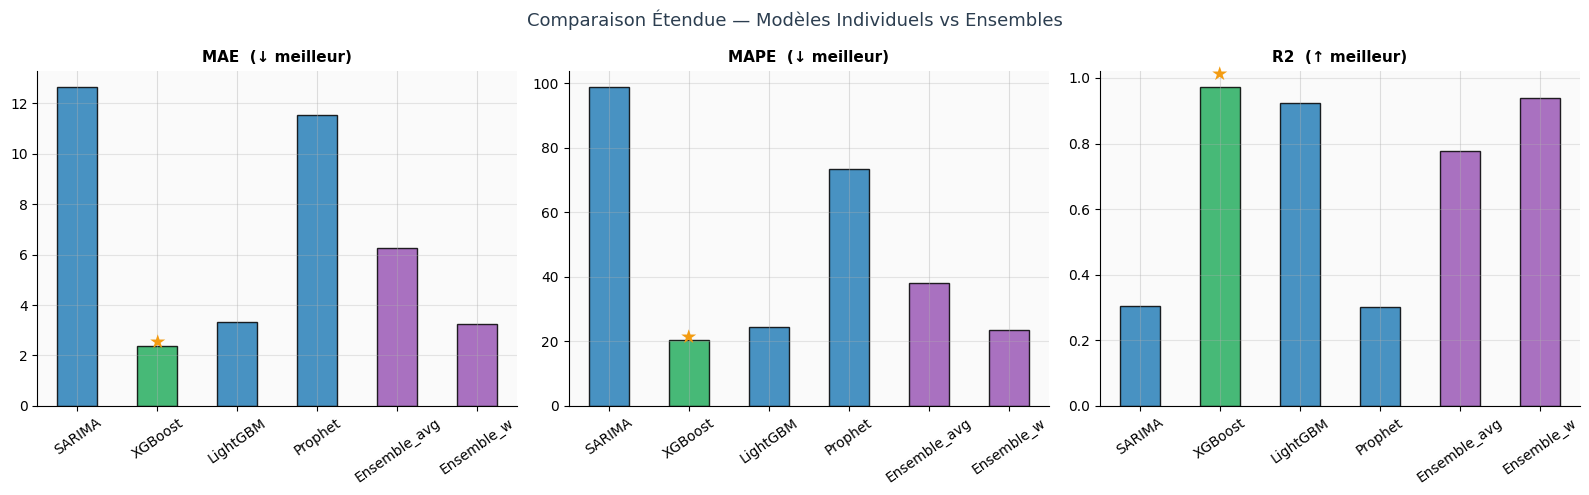

  [SAVED] 04b_ensemble_comparison.png


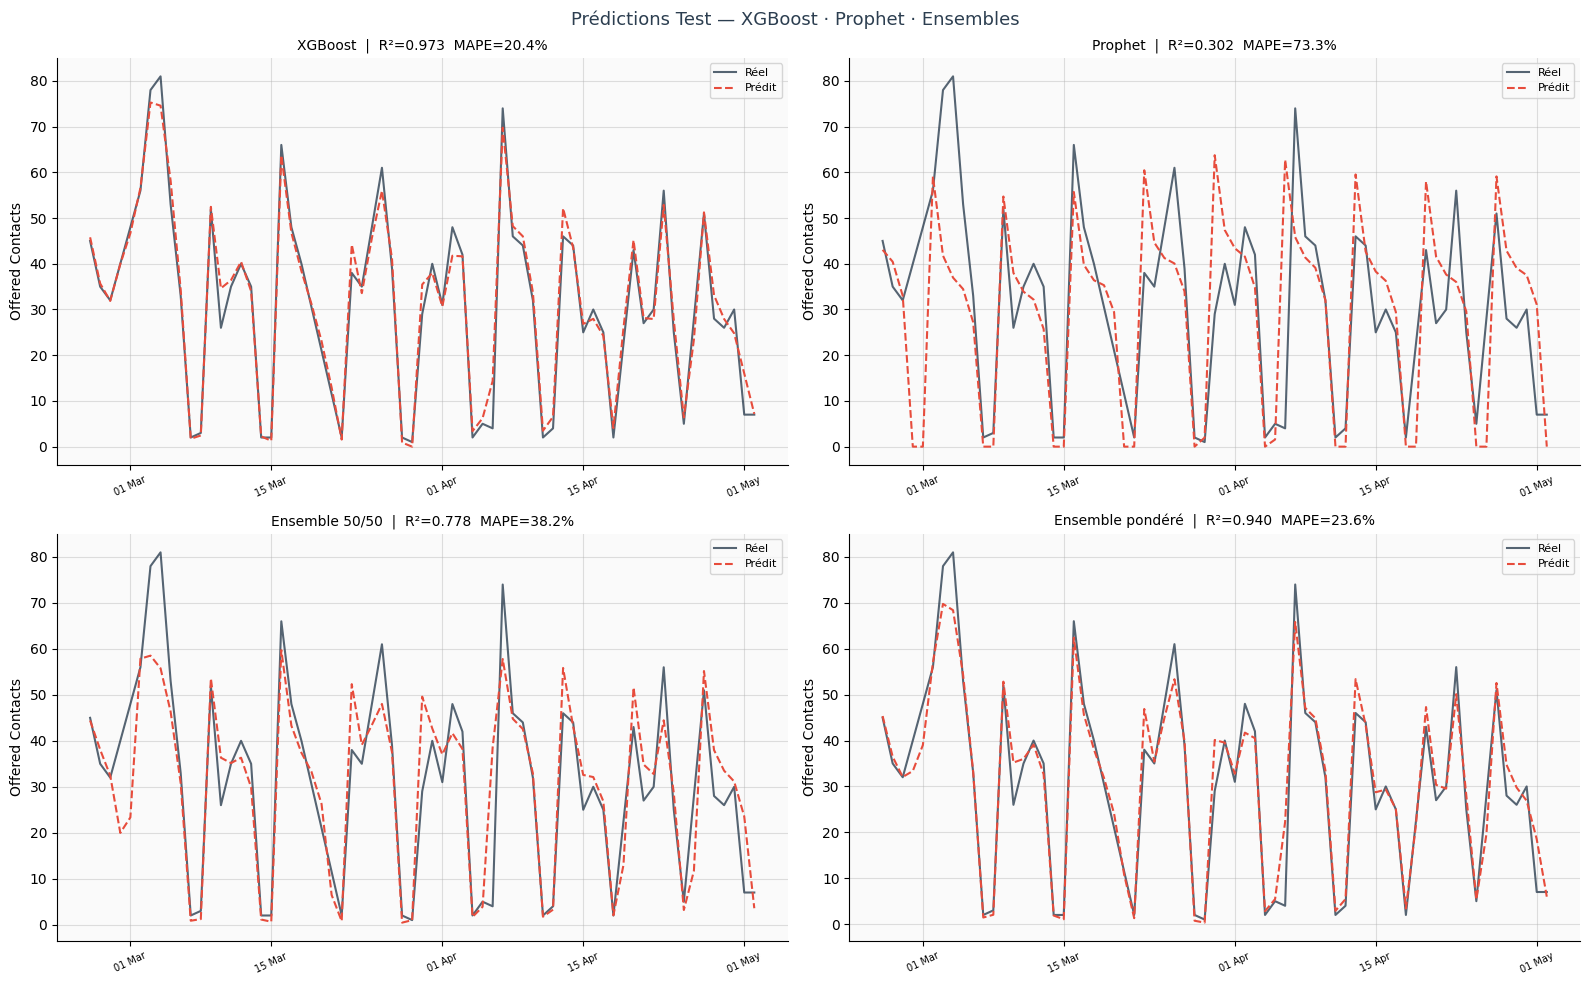

  [SAVED] 05b_ensemble_vs_real.png


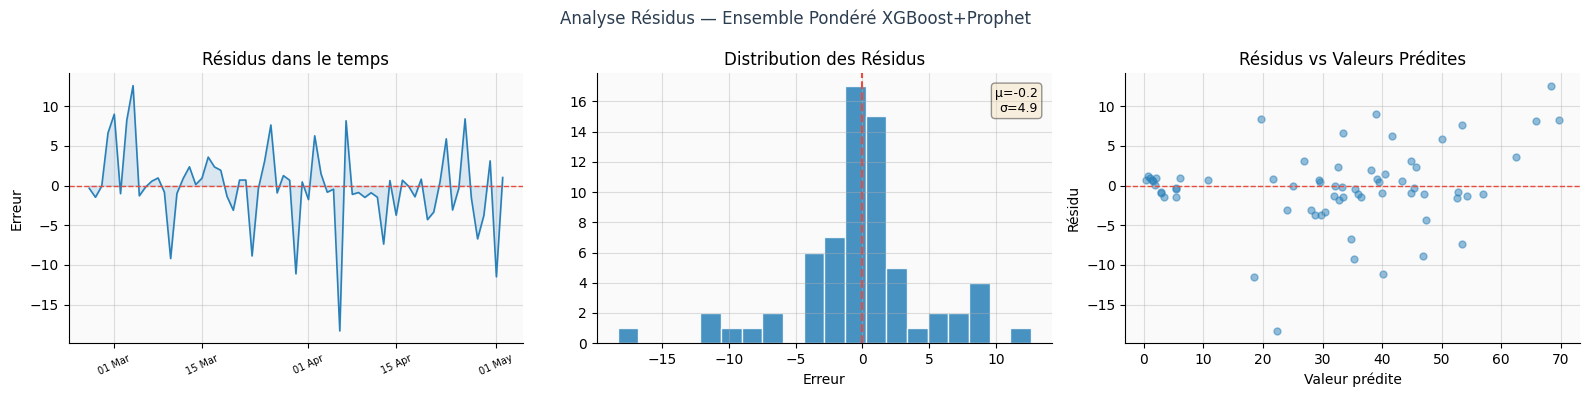

  [SAVED] 06b_ensemble_residuals.png
⚙️  Génération des prévisions individuelles (variables manquantes)...
Prévision XGBoost...
Prévision LightGBM...
✅ Prévisions individuelles générées.


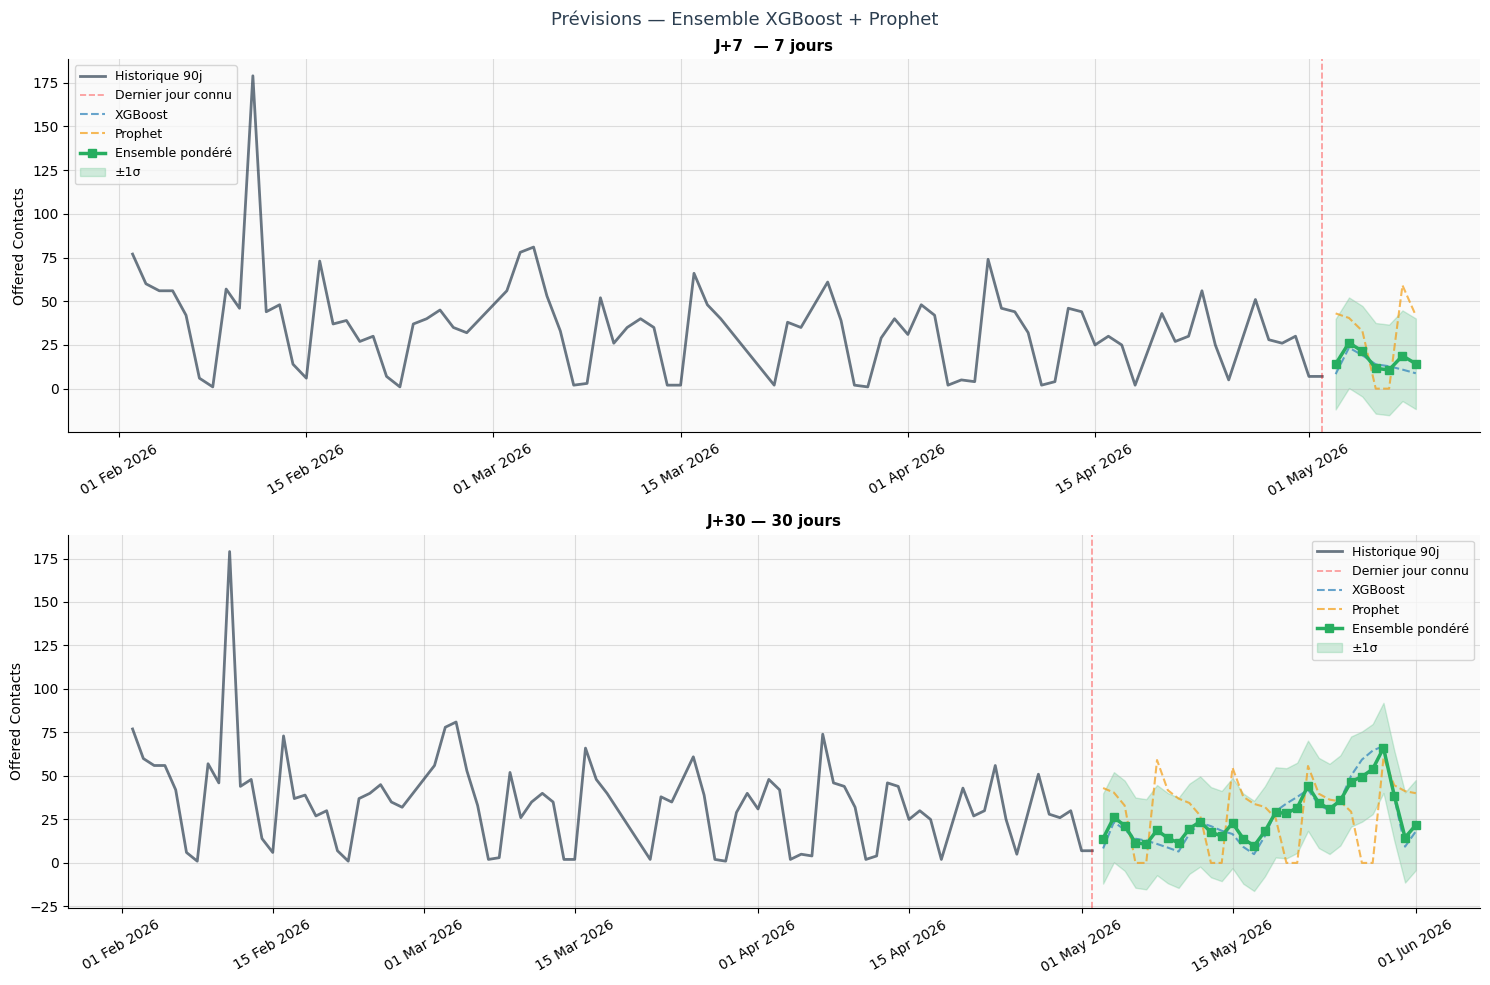

  [SAVED] 09_ensemble_forecasts.png

📅 PRÉVISIONS ENSEMBLISTES J+7
      Date  XGBoost  Prophet  Ensemble_avg  Ensemble_w
2026-05-03      8.3     43.0          25.7        14.0
2026-05-04     23.5     40.5          32.0        26.3
2026-05-05     19.1     33.0          26.0        21.4
2026-05-06     13.9      0.0           7.0        11.6
2026-05-07     12.8      0.0           6.4        10.7
2026-05-08     10.9     59.1          35.0        18.8
2026-05-09      8.8     41.8          25.3        14.2

📅 PRÉVISIONS ENSEMBLISTES J+30 (5 premières lignes)
      Date  XGBoost  Prophet  Ensemble_avg  Ensemble_w
2026-05-03      8.3     43.0          25.7        14.0
2026-05-04     23.5     40.5          32.0        26.3
2026-05-05     19.1     33.0          26.0        21.4
2026-05-06     13.9      0.0           7.0        11.6
2026-05-07     12.8      0.0           6.4        10.7

[SAVED] ensemble_forecast_j7.csv & ensemble_forecast_j30.csv


In [15]:
# ── 1. Stratégies d'ensemble ──────────────────────────────────────────────────
pred_ens_avg = (pred_xgb_test + prophet_test_pred) / 2

rmse_xgb     = results_store["XGBoost"]["RMSE"]
rmse_prophet = results_store["Prophet"]["RMSE"]
w_xgb        = (1 / rmse_xgb)    / (1/rmse_xgb + 1/rmse_prophet)
w_prophet    = (1 / rmse_prophet) / (1/rmse_xgb + 1/rmse_prophet)
pred_ens_w   = w_xgb * pred_xgb_test + w_prophet * prophet_test_pred

print(f"  Poids XGBoost  : {w_xgb:.3f}")
print(f"  Poids Prophet  : {w_prophet:.3f}")

# ── 2. Métriques des deux variantes d'ensemble ────────────────────────────────
results_store["Ensemble_avg"] = compute_metrics(y_test, pred_ens_avg,  "Ensemble (50/50)")
results_store["Ensemble_w"]   = compute_metrics(y_test, pred_ens_w,   f"Ensemble (w={w_xgb:.2f}/{w_prophet:.2f})")

# ── 3. Tableau comparatif étendu ──────────────────────────────────────────────
results_ext = (pd.DataFrame(results_store).T[["MAE","RMSE","MAPE","R2"]]
               .astype(float).round(4))

print("\n" + "="*65)
print("  TABLEAU COMPARATIF ÉTENDU  (modèles individuels + ensembles)")
print("="*65)
print(results_ext.to_string())

best_ext = results_ext["RMSE"].idxmin()
bm_ext   = results_ext.loc[best_ext]
print(f"\n🏆 MEILLEUR MODÈLE (étendu) : {best_ext}")
print(f"   MAE  : {bm_ext['MAE']:.2f}   MAPE : {bm_ext['MAPE']:.2f}%   R² : {bm_ext['R2']:.4f}")

# ── 4. Visualisation — comparaison 6 modèles ──────────────────────────────────
all_colors = [C["secondary"], C["success"], C["warning"], C["accent"],
              "#8E44AD", "#16A085"]
models_ext = list(results_ext.index)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparaison Étendue — Modèles Individuels vs Ensembles",
             fontsize=13, color=C["primary"])

bar_colors_ext = [C["success"] if i == best_ext else
                  ("#9B59B6" if "Ensemble" in i else C["secondary"])
                  for i in models_ext]

for ax, (metric, better) in zip(axes, [("MAE","↓"), ("MAPE","↓"), ("R2","↑")]):
    results_ext[metric].plot(kind="bar", ax=ax, color=bar_colors_ext,
                             edgecolor="black", alpha=0.85)
    ax.set_title(f"{metric}  ({better} meilleur)", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, alpha=0.3, axis="y")
    for i, (idx, val) in enumerate(results_ext[metric].items()):
        if idx == best_ext:
            ax.text(i, val * (0.96 if better == "↓" else 1.02), "★",
                    ha="center", fontsize=14, color=C["warning"])

plt.tight_layout()
save_fig("04b_ensemble_comparison.png")

# ── 5. Prédictions vs Réel — Ensemble vs modèles individuels ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Prédictions Test — XGBoost · Prophet · Ensembles",
             fontsize=13, color=C["primary"])

for ax, (name, preds) in zip(axes.flatten(), [
    ("XGBoost",           pred_xgb_test),
    ("Prophet",           prophet_test_pred),
    ("Ensemble 50/50",    pred_ens_avg),
    ("Ensemble pondéré",  pred_ens_w),
]):
    ax.plot(d_test.index, y_test, color=C["primary"], lw=1.5, label="Réel",   alpha=0.8)
    ax.plot(d_test.index, preds,  color=C["accent"],  lw=1.5, ls="--", label="Prédit")
    m = compute_metrics(y_test, preds)
    ax.set_title(f"{name}  |  R²={m['R2']:.3f}  MAPE={m['MAPE']:.1f}%", fontsize=10)
    ax.legend(fontsize=8); ax.set_ylabel("Offered Contacts")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(ax.get_xticklabels(), rotation=25, fontsize=7)

save_fig("05b_ensemble_vs_real.png")

# ── 6. Analyse des résidus — Ensemble pondéré ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Analyse Résidus — Ensemble Pondéré XGBoost+Prophet",
             fontsize=12, color=C["primary"])

res_ens = y_test - pred_ens_w

ax = axes[0]
ax.plot(d_test.index, res_ens, color=C["secondary"], lw=1.2)
ax.axhline(0, color=C["accent"], ls="--", lw=1)
ax.fill_between(d_test.index, res_ens, 0, alpha=0.15, color=C["secondary"])
ax.set_title("Résidus dans le temps"); ax.set_ylabel("Erreur")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.setp(ax.get_xticklabels(), rotation=25, fontsize=7)

ax = axes[1]
ax.hist(res_ens, bins=20, color=C["secondary"], edgecolor="white", alpha=0.85)
ax.axvline(0, color=C["accent"], ls="--", lw=1.5)
ax.set_title("Distribution des Résidus"); ax.set_xlabel("Erreur")
ax.text(0.97, 0.95, f"μ={res_ens.mean():.1f}\nσ={res_ens.std():.1f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.4))

ax = axes[2]
ax.scatter(pred_ens_w, res_ens, color=C["secondary"], alpha=0.5, s=25)
ax.axhline(0, color=C["accent"], ls="--", lw=1)
ax.set_title("Résidus vs Valeurs Prédites")
ax.set_xlabel("Valeur prédite"); ax.set_ylabel("Résidu")

save_fig("06b_ensemble_residuals.png")

# ── 7. Prévisions J+7 & J+30 de l'ensemble ───────────────────────────────────
if 'xgb_f7' not in dir():
    print("⚙️  Génération des prévisions individuelles (variables manquantes)...")
    last_date = d.index[-1]

    # ── Définition locale de forecast_ml ──────────────────────────────────────
    def forecast_ml(model, d_ref, feature_cols, scaler, mean_cols_list, horizon):
        history = d_ref.copy()
        preds = []
        for step in range(horizon):
            fd = last_date + pd.Timedelta(days=step+1)
            row = dict(day_of_week=fd.dayofweek, month=fd.month,
                       week=fd.isocalendar()[1], is_weekend=int(fd.dayofweek>=5),
                       quarter=fd.quarter)
            for lag in [1,2,3,7,14,21,28]:
                row[f"lag_{lag}"] = history[TARGET].iloc[-lag] if len(history)>=lag else np.nan
            for w in [7,14,28]:
                v = history[TARGET].iloc[-w:].values
                row[f"rolling_mean_{w}"] = np.mean(v)
                row[f"rolling_std_{w}"]  = np.std(v) if len(v)>1 else 0
            row["ema_7"]  = history[TARGET].ewm(span=7,  adjust=False).mean().iloc[-1]
            row["ema_14"] = history[TARGET].ewm(span=14, adjust=False).mean().iloc[-1]
            row["diff_1"] = history[TARGET].diff(1).iloc[-1]
            row["diff_7"] = history[TARGET].diff(7).iloc[-1] if len(history)>=7 else 0
            for c in mean_cols_list:
                if c in feature_cols:
                    row[c] = history[c].iloc[-1] if c in history.columns else 0
            X_row = np.array([[row.get(c, 0) for c in feature_cols]])
            p = max(float(model.predict(scaler.transform(X_row))[0]), 0)
            preds.append(p)
            new_r = pd.DataFrame([{**{c:row.get(c,np.nan) for c in d_ref.columns}, TARGET:p}],
                                 index=[fd])
            history = pd.concat([history, new_r])
        return np.array(preds)

    sarima_f7  = np.maximum(sarima_model.predict(n_periods=7),  0)
    sarima_f30 = np.maximum(sarima_model.predict(n_periods=30), 0)

    prophet_f7  = np.maximum(
        prophet_model.predict(
            prophet_model.make_future_dataframe(periods=7,  freq="D"))["yhat"].iloc[-7:].values,  0)
    prophet_f30 = np.maximum(
        prophet_model.predict(
            prophet_model.make_future_dataframe(periods=30, freq="D"))["yhat"].iloc[-30:].values, 0)

    print("Prévision XGBoost...")
    xgb_f7  = forecast_ml(xgb_model, d, feature_cols, scaler, mean_cols, 7)
    xgb_f30 = forecast_ml(xgb_model, d, feature_cols, scaler, mean_cols, 30)

    print("Prévision LightGBM...")
    lgb_f7  = forecast_ml(lgb_model, d, feature_cols, scaler, mean_cols, 7)
    lgb_f30 = forecast_ml(lgb_model, d, feature_cols, scaler, mean_cols, 30)

    dates_7  = pd.date_range(last_date + pd.Timedelta(days=1), periods=7,  freq="D")
    dates_30 = pd.date_range(last_date + pd.Timedelta(days=1), periods=30, freq="D")

    forecasts = {
        "SARIMA":   (sarima_f7,  sarima_f30),
        "XGBoost":  (xgb_f7,    xgb_f30),
        "LightGBM": (lgb_f7,    lgb_f30),
        "Prophet":  (prophet_f7, prophet_f30),
    }
    print("✅ Prévisions individuelles générées.")

xgb_ens_f7,  xgb_ens_f30  = xgb_f7,  xgb_f30
prop_ens_f7, prop_ens_f30  = prophet_f7, prophet_f30

ens_f7_avg  = (xgb_ens_f7  + prop_ens_f7)  / 2
ens_f30_avg = (xgb_ens_f30 + prop_ens_f30) / 2
ens_f7_w    = w_xgb * xgb_ens_f7  + w_prophet * prop_ens_f7
ens_f30_w   = w_xgb * xgb_ens_f30 + w_prophet * prop_ens_f30

forecasts["Ensemble_avg"] = (ens_f7_avg, ens_f30_avg)
forecasts["Ensemble_w"]   = (ens_f7_w,   ens_f30_w)

hist_w = d[TARGET].iloc[-90:]
std_r  = hist_w.std()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle("Prévisions — Ensemble XGBoost + Prophet", fontsize=13, color=C["primary"])

for ax, (dates, f_xgb, f_prop, f_ens, title) in zip(axes, [
    (dates_7,  xgb_ens_f7,  prop_ens_f7,  ens_f7_w,  "J+7  — 7 jours"),
    (dates_30, xgb_ens_f30, prop_ens_f30, ens_f30_w, "J+30 — 30 jours"),
]):
    ax.plot(hist_w.index, hist_w.values, color=C["primary"], lw=2, label="Historique 90j", alpha=0.7)
    ax.axvline(last_date, color="red", ls="--", alpha=0.4, lw=1.2, label="Dernier jour connu")
    ax.plot(dates, f_xgb,  color=C["secondary"], lw=1.5, ls="--", alpha=0.7, label="XGBoost")
    ax.plot(dates, f_prop, color=C["warning"],   lw=1.5, ls="--", alpha=0.7, label="Prophet")
    ax.plot(dates, f_ens,  color=C["success"],   lw=2.5, marker="s", markersize=6,
            label="Ensemble pondéré")
    ax.fill_between(dates, f_ens - std_r, f_ens + std_r, alpha=0.2,
                    color=C["success"], label="±1σ")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Offered Contacts"); ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=30)

save_fig("09_ensemble_forecasts.png")

# ── 8. Tableau récap des prévisions ensemblistes ─────────────────────────────
df_ens_j7  = pd.DataFrame({"Date":         dates_7.strftime("%Y-%m-%d"),
                            "XGBoost":      xgb_ens_f7.round(1),
                            "Prophet":      prop_ens_f7.round(1),
                            "Ensemble_avg": ens_f7_avg.round(1),
                            "Ensemble_w":   ens_f7_w.round(1)})
df_ens_j30 = pd.DataFrame({"Date":         dates_30.strftime("%Y-%m-%d"),
                            "XGBoost":      xgb_ens_f30.round(1),
                            "Prophet":      prop_ens_f30.round(1),
                            "Ensemble_avg": ens_f30_avg.round(1),
                            "Ensemble_w":   ens_f30_w.round(1)})

print("\n📅 PRÉVISIONS ENSEMBLISTES J+7")
print(df_ens_j7.to_string(index=False))
print("\n📅 PRÉVISIONS ENSEMBLISTES J+30 (5 premières lignes)")
print(df_ens_j30.head(5).to_string(index=False))

df_ens_j7.to_csv(os.path.join(OUTPUT_DIR,  "ensemble_forecast_j7.csv"),  index=False)
df_ens_j30.to_csv(os.path.join(OUTPUT_DIR, "ensemble_forecast_j30.csv"), index=False)
print("\n[SAVED] ensemble_forecast_j7.csv & ensemble_forecast_j30.csv")

## 11. Prédictions vs Réel — Test Set

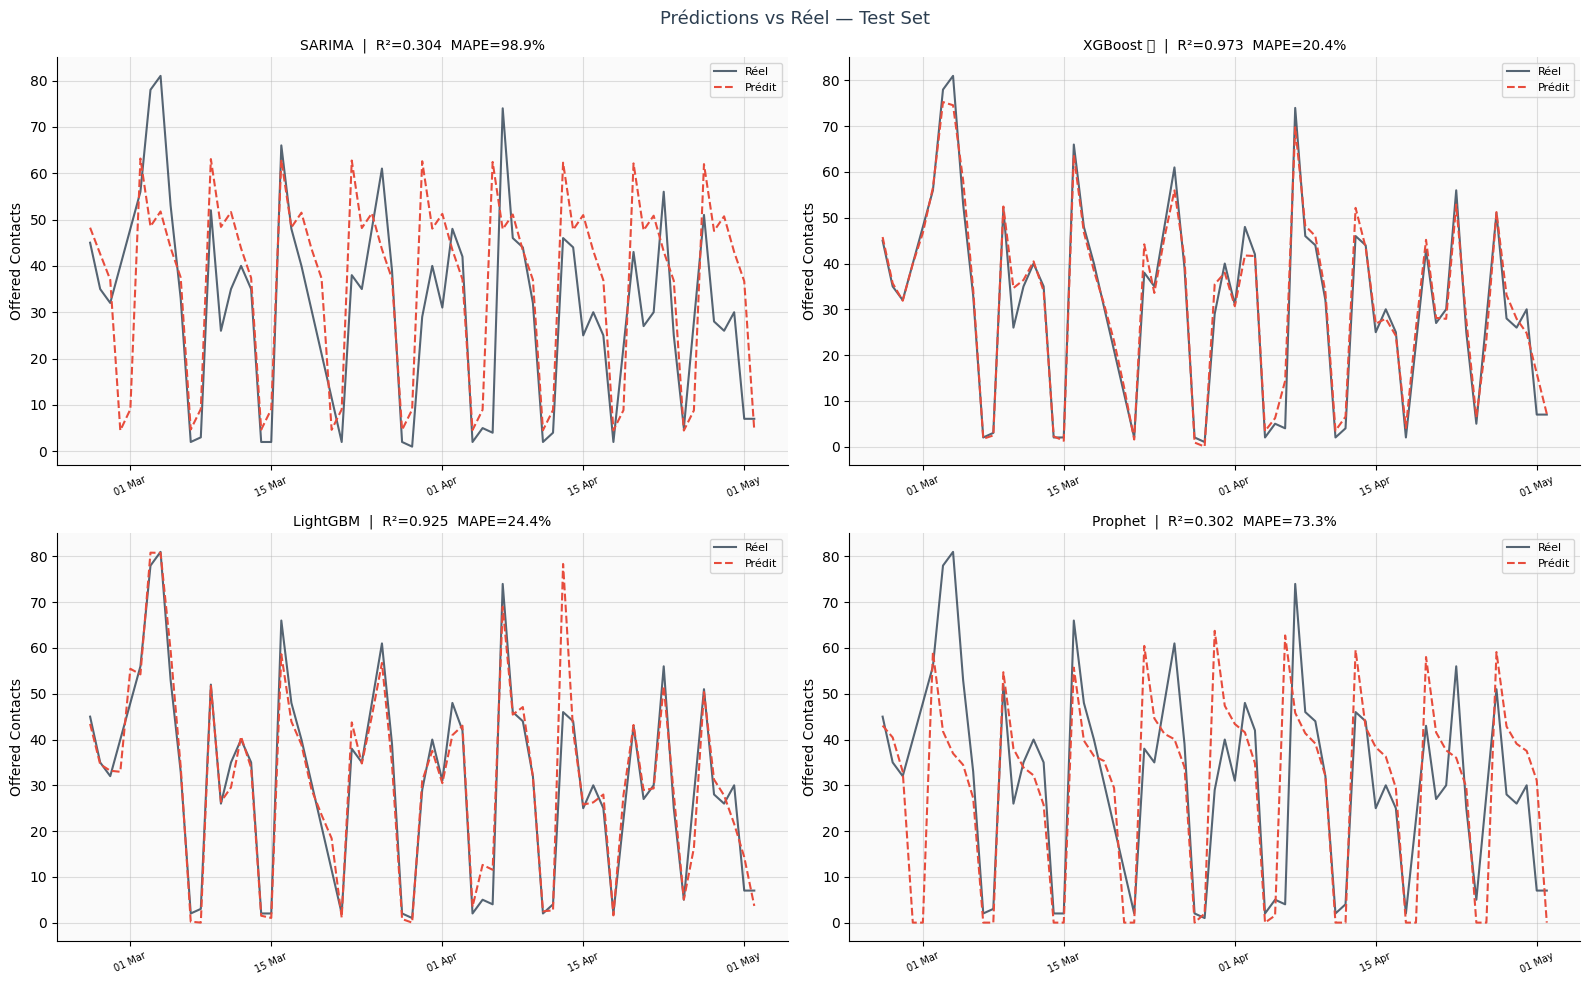

  [SAVED] 05_predictions_vs_real.png


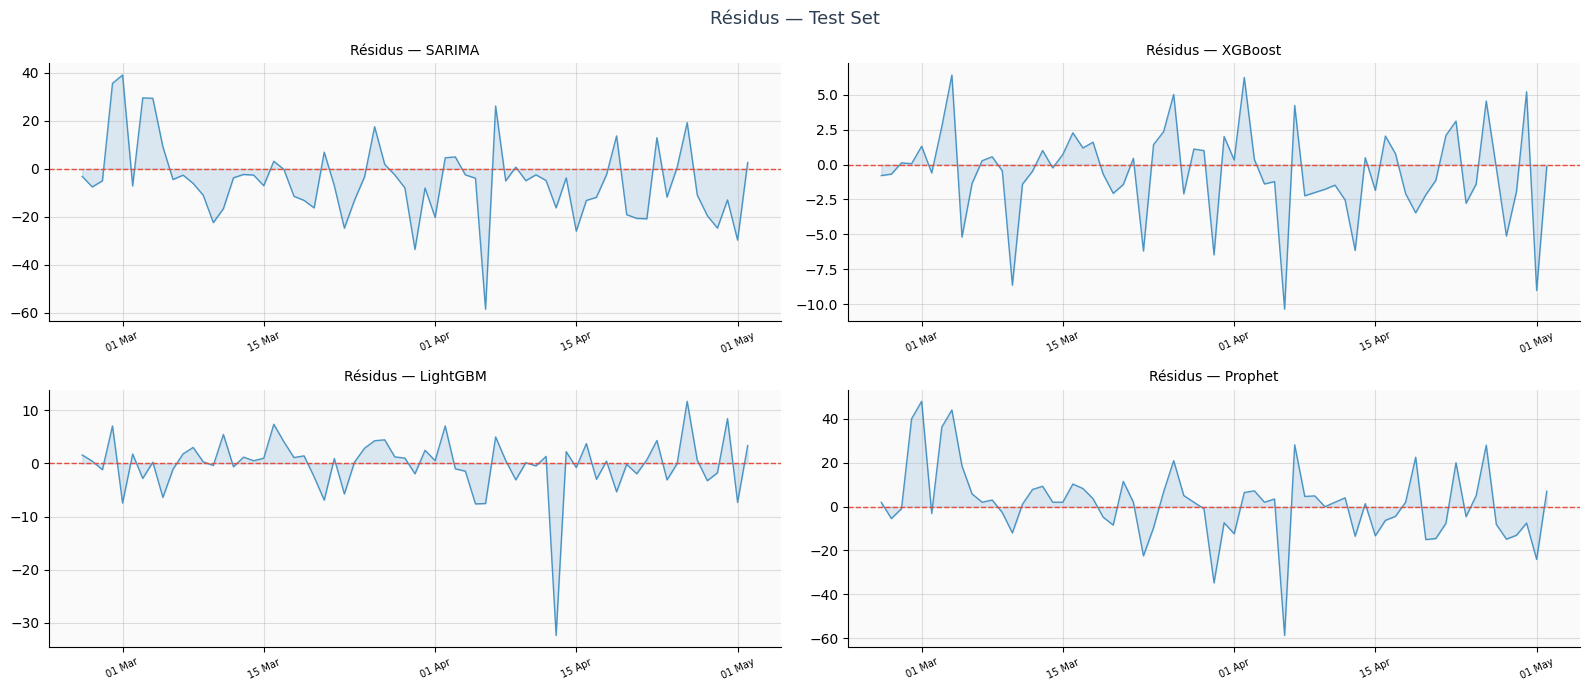

  [SAVED] 06_residuals.png


In [16]:
preds_map = {"SARIMA":sarima_preds,"XGBoost":pred_xgb_test,
             "LightGBM":pred_lgb_test,"Prophet":prophet_test_pred}
test_dates = d_test.index

fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.suptitle("Prédictions vs Réel — Test Set", fontsize=13, color=C["primary"])
for ax,(name,preds) in zip(axes.flatten(), preds_map.items()):
    ax.plot(test_dates, y_test, color=C["primary"], lw=1.5, label="Réel", alpha=0.8)
    ax.plot(test_dates, preds,  color=C["accent"],  lw=1.5, ls="--", label="Prédit")
    star=" 🏆" if name==best_model else ""
    r2=results_store[name]["R2"]; mape=results_store[name]["MAPE"]
    ax.set_title(f"{name}{star}  |  R²={r2:.3f}  MAPE={mape:.1f}%", fontsize=10)
    ax.legend(fontsize=8); ax.set_ylabel("Offered Contacts")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(ax.get_xticklabels(), rotation=25, fontsize=7)
save_fig("05_predictions_vs_real.png")

fig, axes = plt.subplots(2, 2, figsize=(16,7))
fig.suptitle("Résidus — Test Set", fontsize=13, color=C["primary"])
for ax,(name,preds) in zip(axes.flatten(), preds_map.items()):
    res = y_test - preds
    ax.plot(test_dates, res, color=C["secondary"], lw=1, alpha=0.8)
    ax.axhline(0, color=C["accent"], ls="--", lw=1)
    ax.fill_between(test_dates, res, 0, alpha=0.15, color=C["secondary"])
    ax.set_title(f"Résidus — {name}", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(ax.get_xticklabels(), rotation=25, fontsize=7)
save_fig("06_residuals.png")


## 12. Prévisions J+7 & J+30

In [17]:
last_date = d.index[-1]
print(f"Dernier jour connu : {last_date.date()}")

def forecast_ml(model, d_ref, feature_cols, scaler, mean_cols_list, horizon):
    history = d_ref.copy()
    preds = []
    for step in range(horizon):
        fd = last_date + pd.Timedelta(days=step+1)
        row = dict(day_of_week=fd.dayofweek, month=fd.month,
                   week=fd.isocalendar()[1], is_weekend=int(fd.dayofweek>=5),
                   quarter=fd.quarter)
        for lag in [1,2,3,7,14,21,28]:
            row[f"lag_{lag}"] = history[TARGET].iloc[-lag] if len(history)>=lag else np.nan
        for w in [7,14,28]:
            v = history[TARGET].iloc[-w:].values
            row[f"rolling_mean_{w}"] = np.mean(v)
            row[f"rolling_std_{w}"]  = np.std(v) if len(v)>1 else 0
        row["ema_7"]  = history[TARGET].ewm(span=7,  adjust=False).mean().iloc[-1]
        row["ema_14"] = history[TARGET].ewm(span=14, adjust=False).mean().iloc[-1]
        row["diff_1"] = history[TARGET].diff(1).iloc[-1]
        row["diff_7"] = history[TARGET].diff(7).iloc[-1] if len(history)>=7 else 0
        for c in mean_cols_list:
            if c in feature_cols:
                row[c] = history[c].iloc[-1] if c in history.columns else 0
        X_row = np.array([[row.get(c, 0) for c in feature_cols]])
        p = max(float(model.predict(scaler.transform(X_row))[0]), 0)
        preds.append(p)
        new_r = pd.DataFrame([{**{c:row.get(c,np.nan) for c in d_ref.columns}, TARGET:p}],
                             index=[fd])
        history = pd.concat([history, new_r])
    return np.array(preds)

sarima_f7  = np.maximum(sarima_model.predict(n_periods=7),  0)
sarima_f30 = np.maximum(sarima_model.predict(n_periods=30), 0)

prophet_f7  = np.maximum(
    prophet_model.predict(prophet_model.make_future_dataframe(periods=7,  freq="D"))["yhat"].iloc[-7:].values,  0)
prophet_f30 = np.maximum(
    prophet_model.predict(prophet_model.make_future_dataframe(periods=30, freq="D"))["yhat"].iloc[-30:].values, 0)

print("Prévision XGBoost..."); xgb_f7=forecast_ml(xgb_model,d,feature_cols,scaler,mean_cols,7); xgb_f30=forecast_ml(xgb_model,d,feature_cols,scaler,mean_cols,30)
print("Prévision LightGBM..."); lgb_f7=forecast_ml(lgb_model,d,feature_cols,scaler,mean_cols,7); lgb_f30=forecast_ml(lgb_model,d,feature_cols,scaler,mean_cols,30)

forecasts = {"SARIMA":(sarima_f7,sarima_f30),"XGBoost":(xgb_f7,xgb_f30),
             "LightGBM":(lgb_f7,lgb_f30),"Prophet":(prophet_f7,prophet_f30)}

dates_7  = pd.date_range(last_date+pd.Timedelta(days=1), periods=7,  freq="D")
dates_30 = pd.date_range(last_date+pd.Timedelta(days=1), periods=30, freq="D")

df_j7  = pd.DataFrame({"Date": dates_7.strftime("%Y-%m-%d")})
df_j30 = pd.DataFrame({"Date": dates_30.strftime("%Y-%m-%d")})
for name,(f7,f30) in forecasts.items():
    df_j7[name]=f7.round(1); df_j30[name]=f30.round(1)

print("\n📅 PRÉVISIONS J+7")
print(df_j7.to_string(index=False))
print("\n📅 PRÉVISIONS J+30")
print(df_j30.to_string(index=False))

df_j7.to_csv(os.path.join(OUTPUT_DIR,"forecast_j7.csv"),   index=False)
df_j30.to_csv(os.path.join(OUTPUT_DIR,"forecast_j30.csv"), index=False)
print("\n[SAVED] forecast_j7.csv & forecast_j30.csv")


Dernier jour connu : 2026-05-02
Prévision XGBoost...
Prévision LightGBM...

📅 PRÉVISIONS J+7
      Date  SARIMA  XGBoost  LightGBM  Prophet
2026-05-03     NaN      8.3       7.8     43.0
2026-05-04     NaN     23.5      22.7     40.5
2026-05-05     NaN     19.1      10.7     33.0
2026-05-06     NaN     13.9      14.5      0.0
2026-05-07     NaN     12.8      17.7      0.0
2026-05-08     NaN     10.9      12.6     59.1
2026-05-09     NaN      8.8       4.6     41.8

📅 PRÉVISIONS J+30
      Date  SARIMA  XGBoost  LightGBM  Prophet
2026-05-03     NaN      8.3       7.8     43.0
2026-05-04     NaN     23.5      22.7     40.5
2026-05-05     NaN     19.1      10.7     33.0
2026-05-06     NaN     13.9      14.5      0.0
2026-05-07     NaN     12.8      17.7      0.0
2026-05-08     NaN     10.9      12.6     59.1
2026-05-09     NaN      8.8       4.6     41.8
2026-05-10     NaN      6.5       2.3     37.0
2026-05-11     NaN     16.7      17.7     34.5
2026-05-12     NaN     23.1      20.4     

## 13. Visualisation des Prévisions

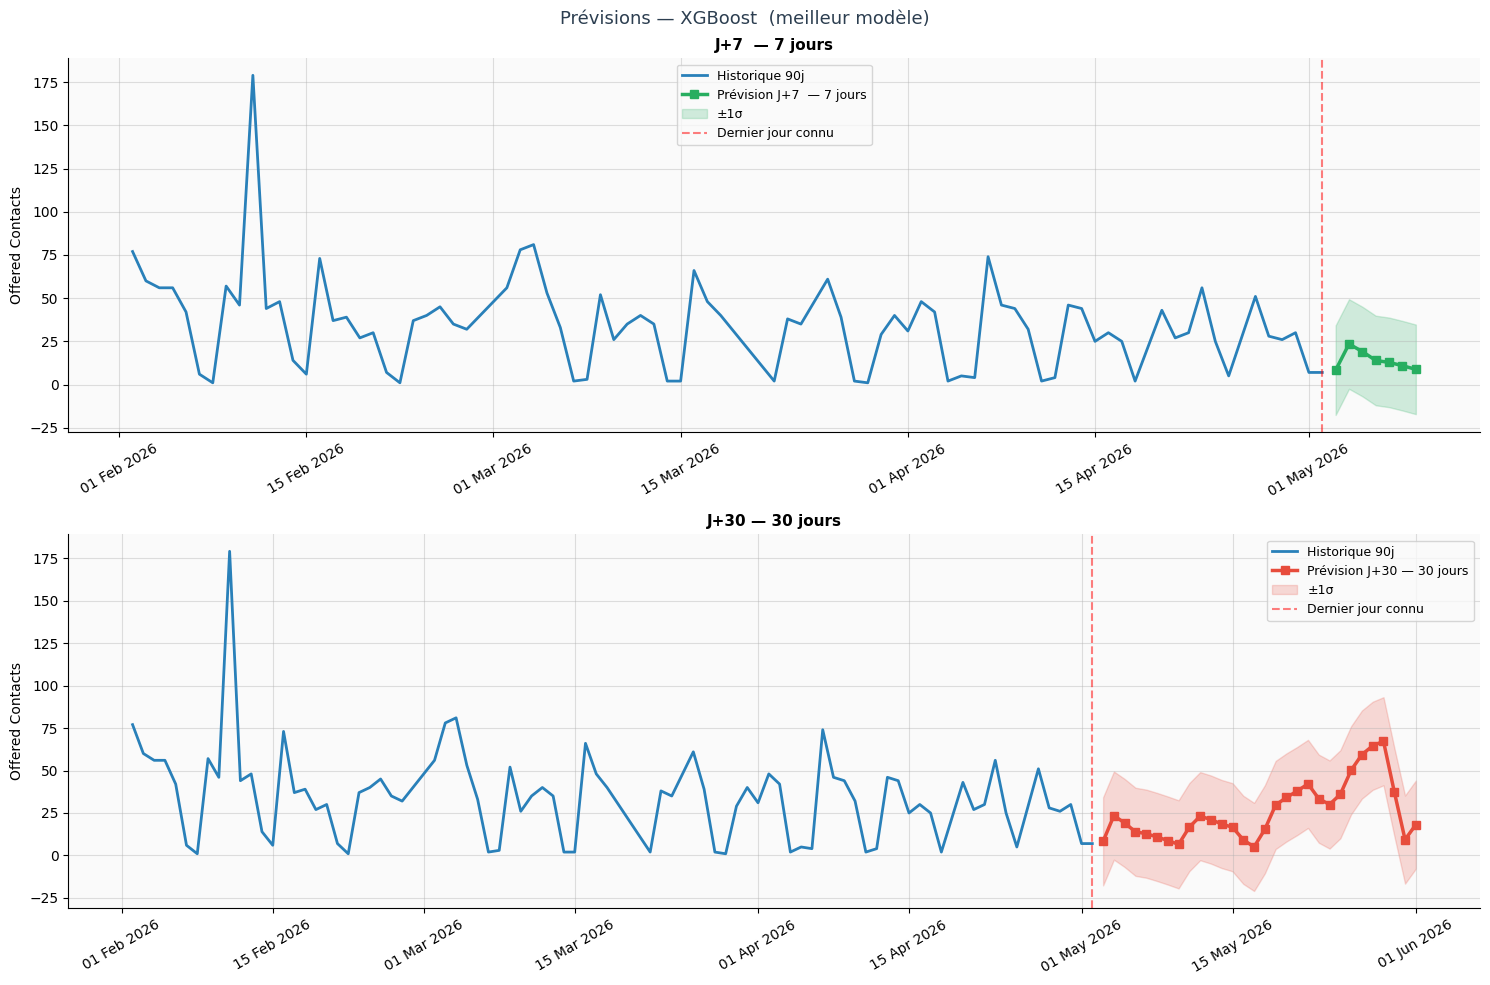

  [SAVED] 07_forecasts.png


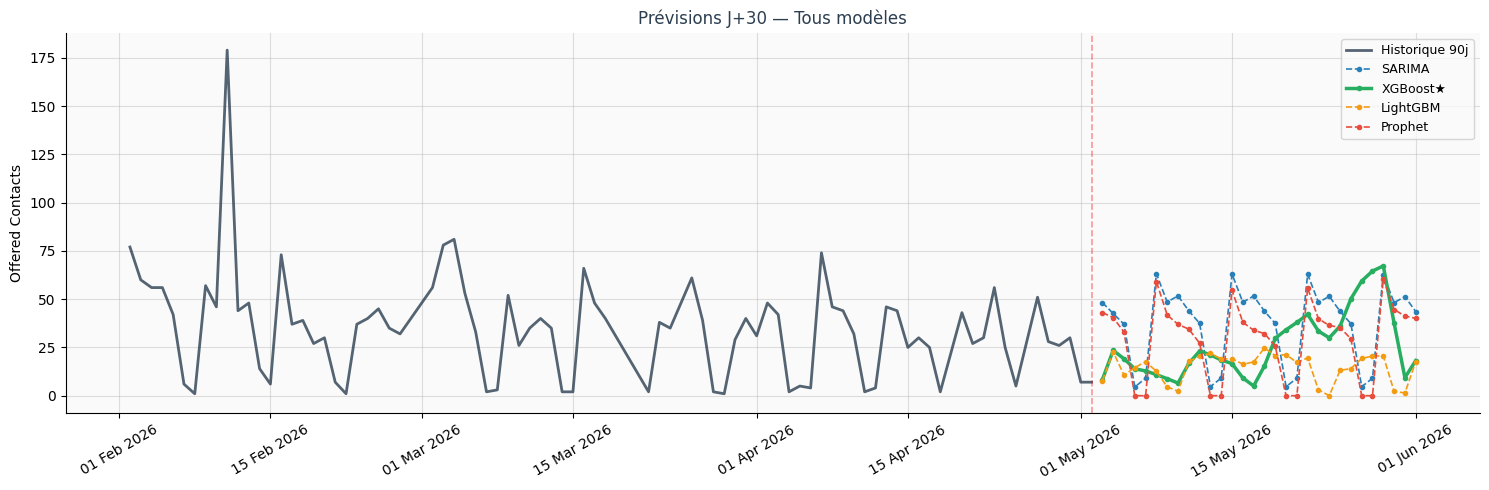

  [SAVED] 08_all_models_j30.png


In [18]:
best_f7, best_f30 = forecasts[best_model]
hist_w = d[TARGET].iloc[-90:]
std_r  = hist_w.std()

fig, axes = plt.subplots(2,1,figsize=(15,10))
fig.suptitle(f"Prévisions — {best_model}  (meilleur modèle)", fontsize=13, color=C["primary"])

for ax,(dates,preds,color,title) in zip(axes,[
    (dates_7,  best_f7,  C["success"],"J+7  — 7 jours"),
    (dates_30, best_f30, C["accent"], "J+30 — 30 jours"),
]):
    ax.plot(hist_w.index, hist_w.values, color=C["secondary"], lw=2, label="Historique 90j")
    ax.plot(dates, preds, color=color, lw=2.5, marker="s", markersize=6, label=f"Prévision {title}")
    ax.fill_between(dates, preds-std_r, preds+std_r, alpha=0.2, color=color, label="±1σ")
    ax.axvline(last_date, color="red", ls="--", alpha=0.5, lw=1.5, label="Dernier jour connu")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Offered Contacts"); ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=30)
save_fig("07_forecasts.png")

# Tous modèles J+30
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(hist_w.index, hist_w.values, color=C["primary"], lw=2, label="Historique 90j", alpha=0.8)
ax.axvline(last_date, color="red", ls="--", alpha=0.4, lw=1.2)
for (name,(_, f30)), col in zip(forecasts.items(),
        [C["secondary"],C["success"],C["warning"],C["accent"]]):
    lw=2.5 if name==best_model else 1.2
    ls="-"  if name==best_model else "--"
    ax.plot(dates_30, f30, color=col, lw=lw, ls=ls,
            label=f"{name}{'★' if name==best_model else ''}", marker=".")
ax.set_title("Prévisions J+30 — Tous modèles", fontsize=12, color=C["primary"])
ax.set_ylabel("Offered Contacts"); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
plt.setp(ax.get_xticklabels(), rotation=30)
save_fig("08_all_models_j30.png")


## 14. Rapport Final

In [19]:
bm = results_df.loc[best_model]
best_f7_arr, best_f30_arr = forecasts[best_model]

print("\n" + "="*65)
print("  RAPPORT FINAL — PIPELINE SERVIER FORECASTING")
print("="*65)
print(f"""
  📌 DONNÉES
  ─────────────────────────────────────────────────────────
  Source   : Servier_KPIs.csv  (sep=';')
  Queues   : French · English · French Password · Spanish
  Cible    : Offered contacts (contacts offerts)
  Période  : {d.index[0].date()} → {last_date.date()}
  Obs.     : {len(d):,} jours après feature engineering

  🏆 RÉSULTATS
  ─────────────────────────────────────────────────────────""")
print(results_df.to_string())
print(f"""
  ✅ MEILLEUR MODÈLE : {best_model}
     MAE   : {bm['MAE']:.2f}  contacts/jour
     RMSE  : {bm['RMSE']:.2f}  contacts/jour
     MAPE  : {bm['MAPE']:.2f}%
     R²    : {bm['R2']:.4f}

  📅 PRÉVISIONS ({best_model})
     J+7   moy={best_f7_arr.mean():.1f}  min={best_f7_arr.min():.1f}  max={best_f7_arr.max():.1f}
     J+30  moy={best_f30_arr.mean():.1f} min={best_f30_arr.min():.1f} max={best_f30_arr.max():.1f}

  💡 RECOMMANDATIONS
  ─────────────────────────────────────────────────────────
  1. Séparer les modèles par queue (French vs English vs Spanish)
  2. Ajouter les jours fériés FR/ES comme variable exogène
  3. Retraining mensuel automatique (Jenkins / APScheduler)
  4. Alerte si MAPE > 25% sur fenêtre glissante 7 jours
  5. Pour horizon > J+30 : envisager TFT ou N-BEATS
""")
print("  📁 Fichiers générés :")
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR,f))//1024
    print(f"     {f}  ({sz} KB)")
print("\n" + "="*65)
print("  ✅  PIPELINE TERMINÉ AVEC SUCCÈS")
print("="*65)



  RAPPORT FINAL — PIPELINE SERVIER FORECASTING

  📌 DONNÉES
  ─────────────────────────────────────────────────────────
  Source   : Servier_KPIs.csv  (sep=';')
  Queues   : French · English · French Password · Spanish
  Cible    : Offered contacts (contacts offerts)
  Période  : 2024-06-29 → 2026-05-02
  Obs.     : 673 jours après feature engineering

  🏆 RÉSULTATS
  ─────────────────────────────────────────────────────────
              MAE     RMSE     MAPE      R2
SARIMA    12.6446  16.8394  98.8707  0.3037
XGBoost    2.3939   3.3234  20.3531  0.9729
LightGBM   3.3290   5.5392  24.4006  0.9247
Prophet   11.5159  16.8663  73.3181  0.3015

  ✅ MEILLEUR MODÈLE : XGBoost
     MAE   : 2.39  contacts/jour
     RMSE  : 3.32  contacts/jour
     MAPE  : 20.35%
     R²    : 0.9729

  📅 PRÉVISIONS (XGBoost)
     J+7   moy=13.9  min=8.3  max=23.5
     J+30  moy=26.0 min=5.0 max=67.2

  💡 RECOMMANDATIONS
  ─────────────────────────────────────────────────────────
  1. Séparer les modèles par q